# Med3Tab-PFN Experiment Results Overview

This notebook consolidates key metrics from Experiment 1 (benchmark comparison) and Experiment 3 (classification head on SAM-Med3D features).

## Setup

Adjust `RESULTS_ROOT` below if your results live in a different path.

In [3]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

ROOT_DIR = Path.cwd()
for _ in range(3):
    if (ROOT_DIR / "results").exists():
        break
    ROOT_DIR = ROOT_DIR.parent

RESULTS_ROOT = ROOT_DIR / "results"
if not RESULTS_ROOT.exists():
    raise FileNotFoundError(
        f"Could not locate results/ directory starting from {Path.cwd()}"
    )

EXP1_DIR = RESULTS_ROOT / "experiment1"
EXP1_AVG_PATH = EXP1_DIR / "average_scores_per_method.csv"
EXP1_DETAIL_PATH = EXP1_DIR / "combined_benchmarks_summary.csv"
EXP3_DIR = RESULTS_ROOT / "classification_head" / "classification_head"
EXP3_SUMMARY_PATH = EXP3_DIR / "summary.csv"

display({"Root directory": ROOT_DIR, "Experiment 1 dir": EXP1_DIR, "Experiment 3 dir": EXP3_DIR})

{'Root directory': WindowsPath('c:/Users/cahel/Desktop/Med3Tab-PFN'),
 'Experiment 1 dir': WindowsPath('c:/Users/cahel/Desktop/Med3Tab-PFN/results/experiment1'),
 'Experiment 3 dir': WindowsPath('c:/Users/cahel/Desktop/Med3Tab-PFN/results/classification_head/classification_head')}

## Load data

In [4]:
exp1_avg = pd.read_csv(EXP1_AVG_PATH)
exp1_detail = pd.read_csv(EXP1_DETAIL_PATH)
exp3_summary = pd.read_csv(EXP3_SUMMARY_PATH)

exp1_avg

,method,n_datasets,avg_accuracy,std_accuracy,avg_macro_f1,std_macro_f1,avg_roc_auc,std_roc_auc
0,densenet121_3d,3,0.750870,0.031313,0.714526,0.031372,0.714033,0.041210
1,tabpfn,3,0.596413,0.084090,0.594284,0.085196,0.630055,0.005785
2,vit3d,3,0.572391,0.115456,0.361636,0.048830,0.532973,0.230755
3,localpfn,2,0.470109,0.134504,0.466346,0.129183,0.498106,0.174098


### Experiment 1: Average scores by method

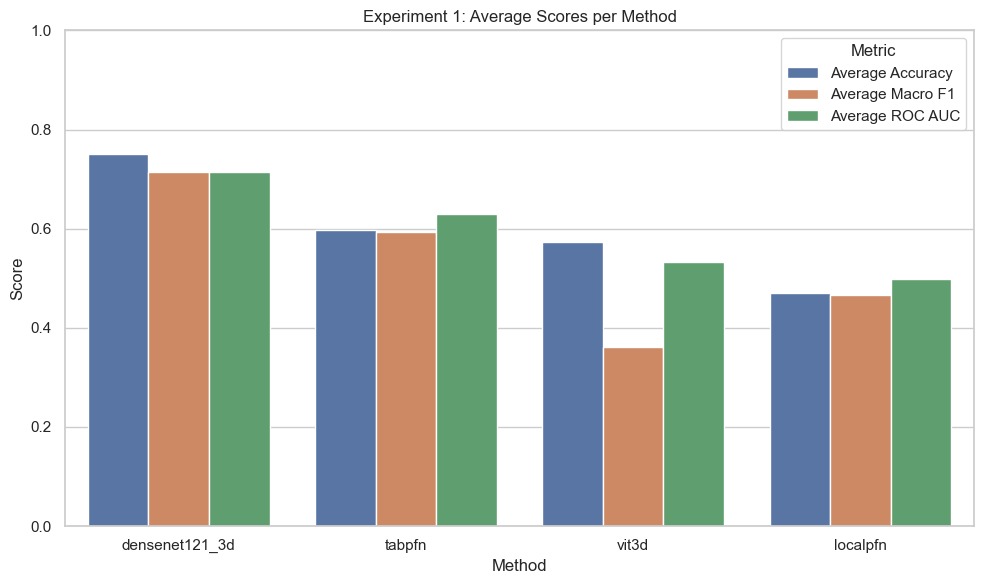

In [5]:
metrics_long = exp1_avg.melt(
    id_vars=["method", "n_datasets"],
    value_vars=["avg_accuracy", "avg_macro_f1", "avg_roc_auc"],
    var_name="metric",
    value_name="score"
)
metric_labels = {
    "avg_accuracy": "Average Accuracy",
    "avg_macro_f1": "Average Macro F1",
    "avg_roc_auc": "Average ROC AUC"
}
metrics_long["metric_label"] = metrics_long["metric"].map(metric_labels)

plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_long, x="method", y="score", hue="metric_label")
plt.ylim(0, 1)
plt.title("Experiment 1: Average Scores per Method")
plt.ylabel("Score")
plt.xlabel("Method")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### Experiment 1: Dataset-level performance (successful runs only)

In [6]:
exp1_success = exp1_detail.dropna(subset=["accuracy"])
exp1_success = exp1_success.assign(method=exp1_success["method"].str.lower())
exp1_success

,dataset,category,ct_name,method,accuracy,macro_f1,roc_auc,out_dir,metrics_path,pred_path,error
0,crlm,crlm,ct_CRLM,tabpfn,0.687500,0.686275,0.625000,/trinity/home/r112276/Med3Tab-PFN/results/expe...,/trinity/home/r112276/Med3Tab-PFN/results/expe...,/trinity/home/r112276/Med3Tab-PFN/results/expe...,NaN
2,gist,gist,ct_GIST,tabpfn,0.580000,0.578483,0.628800,/trinity/home/r112276/Med3Tab-PFN/results/expe...,/trinity/home/r112276/Med3Tab-PFN/results/expe...,/trinity/home/r112276/Med3Tab-PFN/results/expe...,NaN
3,lipo,lipo,ct_LIPO,tabpfn,0.521739,0.518095,0.636364,/trinity/home/r112276/Med3Tab-PFN/results/expe...,/trinity/home/r112276/Med3Tab-PFN/results/expe...,/trinity/home/r112276/Med3Tab-PFN/results/expe...,NaN
6,crlm,crlm,ct_CRLM,localpfn,0.375000,0.375000,0.375000,/trinity/home/r112276/Med3Tab-PFN/results/expe...,/trinity/home/r112276/Med3Tab-PFN/results/expe...,/trinity/home/r112276/Med3Tab-PFN/results/expe...,NaN
9,lipo,lipo,ct_LIPO,localpfn,0.565217,0.557692,0.621212,/trinity/home/r112276/Med3Tab-PFN/results/expe...,/trinity/home/r112276/Med3Tab-PFN/results/expe...,/trinity/home/r112276/Med3Tab-PFN/results/expe...,NaN
12,crlm,crlm,ct_CRLM,densenet121_3d,0.750000,0.733333,0.666667,/trinity/home/r112276/Med3Tab-PFN/notebooks/ba...,NaN,NaN,NaN
13,crlm,crlm,ct_CRLM,vit3d,0.625000,0.384615,0.750000,/trinity/home/r112276/Med3Tab-PFN/notebooks/ba...,NaN,NaN,NaN
16,gist,gist,ct_GIST,densenet121_3d,0.720000,0.678309,0.733766,/trinity/home/r112276/Med3Tab-PFN/notebooks/ba...,NaN,NaN,NaN
17,gist,gist,ct_GIST,vit3d,0.440000,0.305556,0.290584,/trinity/home/r112276/Med3Tab-PFN/notebooks/ba...,NaN,NaN,NaN
18,lipo,lipo,ct_LIPO,densenet121_3d,0.782609,0.731935,0.741667,/trinity/home/r112276/Med3Tab-PFN/notebooks/ba...,NaN,NaN,NaN


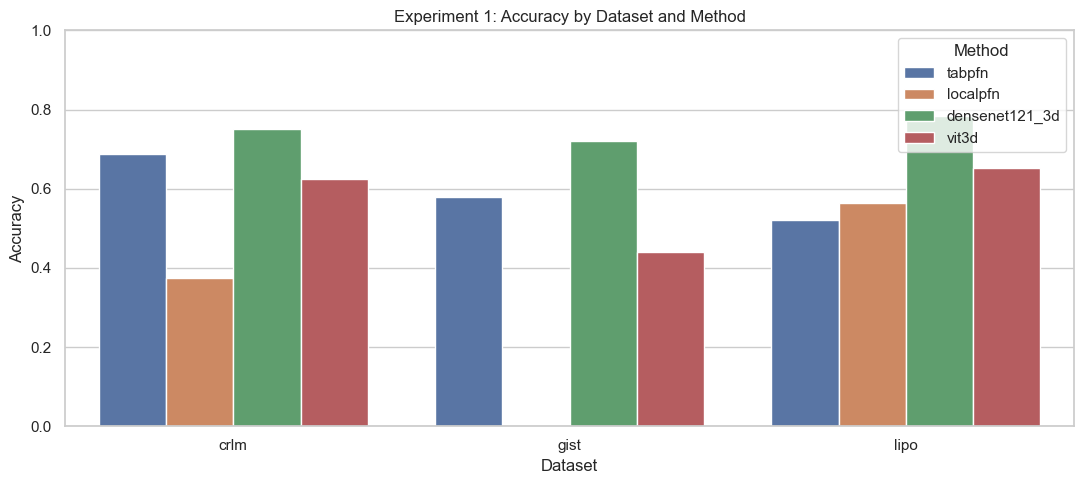

In [7]:
plt.figure(figsize=(11, 5))
sns.barplot(data=exp1_success, x="dataset", y="accuracy", hue="method")
plt.ylim(0, 1)
plt.title("Experiment 1: Accuracy by Dataset and Method")
plt.ylabel("Accuracy")
plt.xlabel("Dataset")
plt.legend(title="Method")
plt.tight_layout()
plt.show()